> **<h3>Scientific Journal Cleaning and Logistic Regression with Decision Tree Text Classification:</h3>**
>
> Dedicate to people who want to learn experiment from boosting Logistic Regression's accuracy with Decision Tree.<br>
> No citation require, I did this with love.

For Pre-Executed Please use [this link](http://601059.surachet-r.net/_FTP/Kaggle/Complete_FCNP.html)<br>
ดูไฟล์แบบรันไว้แล้ว [คลิกที่นี่](http://601059.surachet-r.net/_FTP/Kaggle/Complete_FCNP.html)<br>
<br>
Download .ipynb [here](http://601059.surachet-r.net/_FTP/Kaggle/Complete_FCNP.ipynb)

Final Score: (Late-Submission)
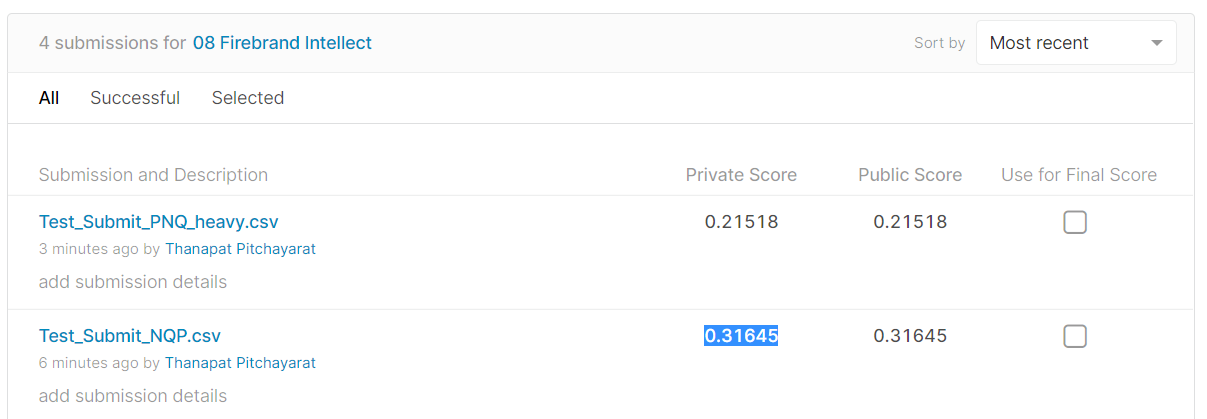

In [ ]:
import pandas as pd
from tqdm import tqdm

In [ ]:
import unicodedata, re, itertools, sys

def remove_control_chars(the_string):
    all_chars = (chr(i) for i in range(sys.maxunicode))
    categories = {'Cc'}
    control_chars = ''.join(c for c in all_chars if unicodedata.category(c) in categories)
    # or equivalently and much more efficiently
    control_chars = ''.join(map(chr, itertools.chain(range(0x00,0x20), range(0x7f,0xa0))))
    
    control_char_re = re.compile('[%s]' % re.escape(control_chars))
    return control_char_re.sub('', the_string)

In [ ]:
def reforge_aiat_dataset(file_target, output_csv_name):
    import pandas
    df = pandas.read_csv(file_target)
    row_n = len(df.index)
    df['text'] = ""
    for x in tqdm(range(0,len(df))):
        folder_name = df['Filename'][x][:5]
        file_name = df['Filename'][x]
        target_location = "train-data/" + folder_name + "/" + file_name
        f = open(target_location, "r", encoding="utf8")
        text_data = f.read()
        df['text'][x] = remove_control_chars(text_data.encode('ascii', 'ignore').decode('utf-8').replace('\n',' '))
        f.close()
    df.to_csv(output_csv_name, index=False)

In [ ]:
reforge_aiat_dataset("train.csv","reforge_train_set.csv")

In [ ]:
df = pd.read_csv("reforge_train_set.csv")

In [ ]:
def reforge_aiat_test_dataset(file_target, output_csv_name):
    import pandas
    df = pandas.read_csv(file_target)
    row_n = len(df.index)
    df['text'] = ""
    for x in tqdm(range(0,len(df))):
        folder_name = df['Id'][x][:5]
        file_name = df['Id'][x]
        target_location = "test-data/test-data/" + folder_name + "/" + file_name
        f = open(target_location, "r", encoding="utf8", errors='ignore')
        text_data = f.read()
        df['text'][x] = remove_control_chars(text_data.encode('ascii', 'ignore').decode('utf-8').replace('\n',' '))
        f.close()
    df.to_csv(output_csv_name, index=False)

In [ ]:
reforge_aiat_test_dataset('test.csv','reforge_test_set.csv')

In [ ]:
df.head()

In [ ]:
import pandas as pd
from tqdm import tqdm

import unicodedata, re, itertools, sys

def remove_control_chars(the_string):
    all_chars = (chr(i) for i in range(sys.maxunicode))
    categories = {'Cc'}
    control_chars = ''.join(c for c in all_chars if unicodedata.category(c) in categories)
    # or equivalently and much more efficiently
    control_chars = ''.join(map(chr, itertools.chain(range(0x00,0x20), range(0x7f,0xa0))))
    
    control_char_re = re.compile('[%s]' % re.escape(control_chars))
    return control_char_re.sub('', the_string)

def reforge_aiat_dataset(file_target, output_csv_name):
    import pandas
    df = pandas.read_csv(file_target)
    row_n = len(df.index)
    df['text'] = ""
    for x in tqdm(range(0,len(df))):
        folder_name = df['Filename'][x][:5]
        file_name = df['Filename'][x]
        target_location = "train-data/" + folder_name + "/" + file_name
        f = open(target_location, "r", encoding="utf8")
        text_data = f.read()
        df['text'][x] = remove_control_chars(text_data.encode('ascii', 'ignore').decode('utf-8').replace('\n',' '))
        f.close()
    df.to_csv(output_csv_name, index=False)

reforge_aiat_dataset("train.csv","reforge_train_set.csv")

df = pd.read_csv("reforge_train_set.csv")

def reforge_aiat_test_dataset(file_target, output_csv_name):
    import pandas
    df = pandas.read_csv(file_target)
    row_n = len(df.index)
    df['text'] = ""
    for x in tqdm(range(0,len(df))):
        folder_name = df['Id'][x][:5]
        file_name = df['Id'][x]
        target_location = "test-data/test-data/" + folder_name + "/" + file_name
        f = open(target_location, "r", encoding="utf8", errors='ignore')
        text_data = f.read()
        df['text'][x] = remove_control_chars(text_data.encode('ascii', 'ignore').decode('utf-8').replace('\n',' '))
        f.close()
    df.to_csv(output_csv_name, index=False)

reforge_aiat_test_dataset('test.csv','reforge_test_set.csv')

df.head()

In [ ]:
import pandas as pd

In [ ]:
data_df = pd.read_csv("reforge_train_set.csv")
data_df.head()

In [ ]:
data_df.count()

In [ ]:
#Check for duplication
data_df['text'].count() - data_df['text'].nunique()

In [ ]:
data_df.drop_duplicates(['text'], inplace=True)

In [ ]:
#Check for duplication
data_df['text'].count() - data_df['text'].nunique()

In [ ]:
#Check more correctness: N/A Data Tuple
data_df.isna().sum()

In [ ]:
data_df.count()

Preprocess

In [ ]:
def sentence_langdetect(dataframe, sentencecolumn):
    # set seed
    DetectorFactory.seed = 0

    # hold label - language
    languages = []

    # go through each text
    for ii in tqdm(range(0,len(dataframe))):
        # split by space into list, take the first x in text, join with space
        text = dataframe.iloc[ii][sentencecolumn].split(" ")
    
        lang = "en"
        try:
            if len(text) > 50:
                lang = detect(" ".join(text[:50]))
            elif len(text) > 0:
                lang = detect(" ".join(text[:len(text)]))
        # ught... beginning of the document was not in a good format
        except Exception as e:
            all_words = set(text)
            try:
                lang = detect(" ".join(all_words))
            # what!! :( let's see if we can find any text in abstract...
            except Exception as e:
                lang = "unknown"
                pass
    
        # get the language    
        languages.append(lang)
        
    languages_dict = {}
    for lang in set(languages):
        languages_dict[lang] = languages.count(lang)
    print("Report of Detected Language:")
    print(languages_dict)
    return languages

In [ ]:
from tqdm import tqdm
import nltk
from langdetect import detect
from langdetect import DetectorFactory

In [ ]:
data_languages = sentence_langdetect(data_df, 'text')

In [ ]:
data_df['language'] = data_languages

In [ ]:
data_df = data_df[data_df['language'] == 'en']
del data_df['language']

In [ ]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import en_core_sci_lg
import string
from nltk.corpus import stopwords

In [ ]:
punctuations = string.punctuation
stopwords = list(STOP_WORDS)
custom_stop_words_academicpaper = [
    'doi', 'preprint', 'copyright', 'peer', 'reviewed', 'org', 'https', 'et', 'al', 'author', 'figure', 
    'rights', 'reserved', 'permission', 'used', 'using', 'biorxiv', 'medrxiv', 'license', 'fig', 'fig.', 
    'al.', 'Elsevier', 'PMC', 'CZI', 'www'
]

for w in custom_stop_words_academicpaper:
    if w not in stopwords:
        stopwords.append(w)

In [ ]:
parser = en_core_sci_lg.load(disable=["tagger", "ner"])
parser.max_length = 7000000

def clean_spacy_tokenizer(dirty):
    mytokens = parser(dirty)
    mytokens = [ word.lemma_.lower().strip() if word.lemma_ != "-PRON-" else word.lower_ for word in mytokens ]
    mytokens = [ word for word in mytokens if word not in stopwords and word not in punctuations ]
    mytokens = " ".join([i for i in mytokens])
    return mytokens

In [ ]:
tqdm.pandas()
data_df['text'] = data_df['text'].progress_apply(clean_spacy_tokenizer)

In [ ]:
data_df.head()

In [ ]:
data_df['word_count'] = data_df['text'].apply(lambda x: len(x.strip().split()))
data_df['unique_words'] = data_df['text'].apply(lambda x:len(set(str(x).split())))

In [ ]:
import seaborn as sns

In [ ]:
sns.distplot(data_df['word_count'])
data_df['word_count'].describe()

In [ ]:
sns.distplot(data_df['unique_words'])
data_df['unique_words'].describe()

Feature Engineering

In [ ]:
data_df.groupby('Blinding of intervention').size()

In [ ]:
def blinding_label(row, targetcolumn):
    if (row[targetcolumn] == 'N'):
        return 0
    if (row[targetcolumn] == 'P'):
        return 1
    if (row[targetcolumn] == 'Q'):
        return 2
    return -1 #In case of invalid input detection

In [ ]:
def blinding_positive(row, targetcolumn):
    if (row[targetcolumn] == 'N'):
        return 0
    if (row[targetcolumn] == 'P'):
        return 1
    if (row[targetcolumn] == 'Q'):
        return 0
    return -1 #In case of invalid input detection

In [ ]:
def blinding_negative(row, targetcolumn):
    if (row[targetcolumn] == 'N'):
        return 1
    if (row[targetcolumn] == 'P'):
        return 0
    if (row[targetcolumn] == 'Q'):
        return 0
    return -1 #In case of invalid input detection

In [ ]:
def blinding_question(row, targetcolumn):
    if (row[targetcolumn] == 'N'):
        return 0
    if (row[targetcolumn] == 'P'):
        return 0
    if (row[targetcolumn] == 'Q'):
        return 1
    return -1 #In case of invalid input detection

In [ ]:
data_df.groupby('Classes').size()

In [ ]:
def pair_of_blinding_label(row, targetcolumn):
    if (row[targetcolumn] == 'NN'):
        return 0
    if (row[targetcolumn] == 'NP'):
        return 1
    if (row[targetcolumn] == 'NQ'):
        return 2
    if (row[targetcolumn] == 'PP'):
        return 3
    if (row[targetcolumn] == 'PQ'):
        return 4
    if (row[targetcolumn] == 'QN'):
        return 5
    if (row[targetcolumn] == 'QP'):
        return 6
    if (row[targetcolumn] == 'QQ'):
        return 7
    if (row[targetcolumn] == 'PN'):
        return 8
    return -1 #In case of invalid input detection

In [ ]:
def extract_feature(extraction, dataframe, targetcolumn):
    if 'extracted_feature' in dataframe:
        ovewriting = 1
    else:
        ovewriting = 0
    dataframe['extracted_feature'] = dataframe.apply (lambda row: extraction(row, targetcolumn), axis=1)
    if ovewriting == 1:
        result = "Extraction complete and did overwrite on latest 'extracted_feature'"
    elif ovewriting == 0:
        result = "Extraction complete"
    if -1 in dataframe['extracted_feature'].unique():
        result = "ERR: Some or all record of this dataframe of feature cannot be extract with this extraction, or user may make an incorrect call"
        del dataframe['extracted_feature']
        if ovewriting == 1:
            result = result + "\nNOTE: Your 'extracted_feature' is corrupted and has been removed"
    return print(result)

In [ ]:
extract_feature(blinding_label, data_df, "Blinding of intervention")
data_df['BoI_Class'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_label, data_df, "Blinding of Outcome assessment")
data_df['BoA_Class'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(pair_of_blinding_label, data_df, "Classes")
data_df['Pair_Class'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_positive, data_df, "Blinding of intervention")
data_df['BoI_P'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_positive, data_df, "Blinding of Outcome assessment")
data_df['BoA_P'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_negative, data_df, "Blinding of intervention")
data_df['BoI_N'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_negative, data_df, "Blinding of Outcome assessment")
data_df['BoA_N'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_question, data_df, "Blinding of intervention")
data_df['BoI_Q'] = data_df['extracted_feature']
del data_df['extracted_feature']

extract_feature(blinding_question, data_df, "Blinding of Outcome assessment")
data_df['BoA_Q'] = data_df['extracted_feature']
del data_df['extracted_feature']

In [ ]:
data_df.sample(n=8, random_state=4)

In [ ]:
data_df.to_csv('data/FCNP/Train_Heavy.csv', index = False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Enter spliting percentage here (Sum of them must equal 100).
TrainSize = 70
ValSize = 15
TestSize = 15

In [ ]:
def spliter(dataframe, labelcolumn, TrainSize, ValSize, TestSize):
    X_train=[]
    y_train=[]
    X_val=[]
    y_val=[]
    X_test=[]
    y_test=[]
    SumSize = TrainSize + ValSize + TestSize
    if (SumSize != 100):
        err = 1
    else:
        err = 0
    if err != 1:
        X = dataframe
        y = LabelEncoder().fit_transform(dataframe[labelcolumn])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(TestSize/100), random_state=1)
        subsplit = (1/((100-TestSize)/ValSize))
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=subsplit, random_state=1)
        X_train = X_train.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        X_val = X_val.reset_index(drop=True)
    elif err == 1:
        print("ERR: Dataframe spliting scale incorrect, make sure sum of them must equal to 100")
    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
# Y is not neccesary at this step, but make sure to declare it correct
X_train, y_train, X_val, y_val, X_test, y_test = spliter(data_df, 'Blinding of intervention', TrainSize, ValSize, TestSize)

In [ ]:
X_train.to_csv('data/FCNP/Train.csv', index = False)
X_val.to_csv('data/FCNP/Val.csv', index = False)
X_test.to_csv('data/FCNP/Test.csv', index = False)

In [ ]:
del data_df, X_train, y_train, X_val, y_val, X_test, y_test
#Optional: For restore used memory space.

Data Loading

In [ ]:
df_train = pd.read_csv("data/FCNP/Train.csv")
df_val = pd.read_csv("data/FCNP/Val.csv")
#Keep Test set for later! make it like real hackaton senario.

In [ ]:
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
start_time = datetime.now()

# create a count vectorizer object 
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(df_train['text'])

# transform the training and validation data using count vectorizer object
xtrain_count =  count_vect.transform(df_train['text'])
xvalid_count =  count_vect.transform(df_val['text'])

# word level tf-idf
tfidf_vect = TfidfVectorizer(analyzer='word', max_features=4096)
tfidf_vect.fit(df_train['text'])
xtrain_tfidf =  tfidf_vect.transform(df_train['text'])
xvalid_tfidf =  tfidf_vect.transform(df_val['text'])

time_elapsed = datetime.now() - start_time
print('Time elapsed (hh:mm:ss.ms) {}'.format(time_elapsed))

In [ ]:
from sklearn import model_selection, preprocessing, linear_model, metrics

In [ ]:
def train_model(classification, feature_vector_train, label):
    # fit the training dataset on the classifier
    classification.fit(feature_vector_train, label)
    return classification

In [ ]:
def predict_model(classifier, feature_vector_valid, label):
    # predict the labels on validation dataset
    predictions = classifier.predict(feature_vector_valid)
    return metrics.accuracy_score(predictions, label)

In [ ]:
def do_classify(dataframe, Name_of_Pred, x_train, x_val, y_train, y_val):
    LR_WordTFIDF_classifier = train_model(linear_model.LogisticRegression(), x_train, y_train)
    LR_WordTFIDF_accuracy = predict_model(LR_WordTFIDF_classifier, x_val, y_val)
    LR_WordTFIDF_predictions = LR_WordTFIDF_classifier.predict(x_val)
    temp_df = dataframe
    temp_df[Name_of_Pred] = LR_WordTFIDF_predictions
    #temp_df = temp_df[temp_df[Name_of_Pred] != 1]
    return temp_df, LR_WordTFIDF_accuracy

In [ ]:
BoI_P_df_val, BoI_P_Acc = do_classify(df_val, 'Pred_BoI_P', xtrain_tfidf, xvalid_tfidf, df_train['BoI_P'], df_val['BoI_P'])
BoI_Q_df_val, BoI_Q_Acc = do_classify(df_val, 'Pred_BoI_Q', xtrain_tfidf, xvalid_tfidf, df_train['BoI_Q'], df_val['BoI_Q'])
BoI_N_df_val, BoI_N_Acc = do_classify(df_val, 'Pred_BoI_N', xtrain_tfidf, xvalid_tfidf, df_train['BoI_N'], df_val['BoI_N'])

In [ ]:
BoI_P_Acc

In [ ]:
BoI_Q_Acc

In [ ]:
BoI_N_Acc

In [ ]:
BoA_P_df_val, BoA_P_Acc = do_classify(df_val, 'Pred_BoA_P', xtrain_tfidf, xvalid_tfidf, df_train['BoA_P'], df_val['BoA_P'])
BoA_Q_df_val, BoA_Q_Acc = do_classify(df_val, 'Pred_BoA_Q', xtrain_tfidf, xvalid_tfidf, df_train['BoA_Q'], df_val['BoA_Q'])
BoA_N_df_val, BoA_N_Acc = do_classify(df_val, 'Pred_BoA_N', xtrain_tfidf, xvalid_tfidf, df_train['BoA_N'], df_val['BoA_N'])

In [ ]:
BoA_P_Acc

In [ ]:
BoA_Q_Acc

In [ ]:
BoA_N_Acc

In [ ]:
def blinding_predict(row, x_p_column, y_p_column, x_q_column, y_q_column, x_n_column, y_n_column):
    if (((row[x_p_column] == 0) & (row[y_p_column] == 0)) & ((row[x_q_column] == 0) & (row[y_q_column] == 0)) & ((row[x_n_column] == 1) & (row[y_n_column] == 1))):
        return 0
    if (((row[x_p_column] == 1) & (row[y_p_column] == 1)) & ((row[x_q_column] == 0) & (row[y_q_column] == 0)) & ((row[x_n_column] == 0) & (row[y_n_column] == 0))):
        return 1
    if (((row[x_p_column] == 0) & (row[y_p_column] == 0)) & ((row[x_q_column] == 1) & (row[y_q_column] == 1)) & ((row[x_n_column] == 0) & (row[y_n_column] == 0))):
        return 2
    return -1 #In case of invalid input detection

In [ ]:
def do_validation(validation, dataframe, x_p_column, y_p_column, x_q_column, y_q_column, x_n_column, y_n_column):
    if 'validate_result' in dataframe:
        ovewriting = 1
    else:
        ovewriting = 0
    dataframe['validate_result'] = dataframe.apply (lambda row: validation(row, x_p_column, y_p_column, x_q_column, y_q_column, x_n_column, y_n_column), axis=1)
    if ovewriting == 1:
        result = "Validation complete and did overwrite on latest 'validate_result'"
    elif ovewriting == 0:
        result = "Validation complete"
    #if -1 in dataframe['validate_result'].unique():
    #    result = "ERR: Some or all record of this dataframe of feature cannot be validate with this validation, or user may make an incorrect call"
    #    del dataframe['validate_result']
    #    if ovewriting == 1:
    #        result = result + "\nNOTE: Your 'validate_result' is corrupted and has been removed"
    #return print(result)

In [ ]:
def score_validate_result(dataframe, y_column):
    sum_score = dataframe[dataframe[y_column] == 0][y_column].count() + dataframe[dataframe[y_column] == 1][y_column].count() + dataframe[dataframe[y_column] == 2][y_column].count()
    accuracy = (sum_score / dataframe[y_column].count()) * 100
    return accuracy

In [ ]:
def order_evaluate(dataframe, BlindType, N_df, P_df, Q_df):
    temp_df = dataframe
    #df_xX <-- x = positive or negative, X = is N or P or Q
    df_pN = temp_df[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nN = temp_df[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    
    df_nN_pQ = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nN_nQ = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    df_nN_nQ_pP = df_nN_nQ[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] != 1])].dropna()
    df_nN_nQ_pP['Pred_'+BlindType+'_P'] = 1.0
    df_NQP = pd.concat([df_pN, df_nN_pQ, df_nN_nQ_pP], ignore_index=False).sort_index()
    
    df_nN_pP = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nN_nP = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    df_nN_nP_pQ = df_nN_nQ[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] != 1])].dropna()
    df_nN_nP_pQ['Pred_'+BlindType+'_Q'] = 1.0
    df_NPQ = pd.concat([df_pN, df_nN_pP, df_nN_nP_pQ], ignore_index=False).sort_index()
    
    
    df_pP = temp_df[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nP = temp_df[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    
    df_nP_pQ = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nP_nQ = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    df_nP_nQ_pN = df_nP_nQ[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] != 1])].dropna()
    df_nP_nQ_pN['Pred_'+BlindType+'_N'] = 1.0
    df_PQN = pd.concat([df_pP, df_nP_pQ, df_nP_nQ_pN], ignore_index=False).sort_index()
    
    df_nP_pN = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nP_nN = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    df_nP_nN_pQ = df_nP_nN[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] != 1])].dropna()
    df_nP_nN_pQ['Pred_'+BlindType+'_Q'] = 1.0
    df_PNQ = pd.concat([df_pP, df_nP_pN, df_nP_nN_pQ], ignore_index=False).sort_index()
    
    
    df_pQ = temp_df[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nQ = temp_df[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    
    df_nQ_pP = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nQ_nP = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    df_nQ_nP_pN = df_nQ_nP[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] != 1])].dropna()
    df_nQ_nP_pN['Pred_'+BlindType+'_N'] = 1.0
    df_QPN = pd.concat([df_pQ, df_nQ_pP, df_nQ_nP_pN], ignore_index=False).sort_index()
    
    df_nQ_pN = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nQ_nN = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    df_nQ_nN_pP = df_nQ_nN[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] != 1])].dropna()
    df_nQ_nN_pP['Pred_'+BlindType+'_P'] = 1.0
    df_QNP = pd.concat([df_pQ, df_nQ_pN, df_nQ_nN_pP], ignore_index=False).sort_index()
    
    
    
    do_validation(blinding_predict, df_NQP, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_NQP[''+BlindType+'_Validate'] = df_NQP['validate_result']
    del df_NQP['validate_result']
    vars()[BlindType+'_NQP'] = score_validate_result(df_NQP, ''+BlindType+'_Validate')
    print(''+BlindType+'_NQP:', vars()[BlindType+'_NQP'])
    
    do_validation(blinding_predict, df_NPQ, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_NPQ[''+BlindType+'_Validate'] = df_NPQ['validate_result']
    del df_NPQ['validate_result']
    vars()[BlindType+'_NPQ'] = score_validate_result(df_NPQ, ''+BlindType+'_Validate')
    print(''+BlindType+'_NPQ:', vars()[BlindType+'_NPQ'])
    
    do_validation(blinding_predict, df_PQN, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_PQN[''+BlindType+'_Validate'] = df_PQN['validate_result']
    del df_PQN['validate_result']
    vars()[BlindType+'_PQN'] = score_validate_result(df_PQN, ''+BlindType+'_Validate')
    print(''+BlindType+'_PQN:', vars()[BlindType+'_PQN'])
    
    do_validation(blinding_predict, df_PNQ, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_PNQ[''+BlindType+'_Validate'] = df_PNQ['validate_result']
    del df_PNQ['validate_result']
    vars()[BlindType+'_PNQ'] = score_validate_result(df_PNQ, ''+BlindType+'_Validate')
    print(''+BlindType+'_PNQ:', vars()[BlindType+'_PNQ'])
    
    do_validation(blinding_predict, df_QPN, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_QPN[''+BlindType+'_Validate'] = df_QPN['validate_result']
    del df_QPN['validate_result']
    vars()[BlindType+'_QPN'] = score_validate_result(df_QPN, ''+BlindType+'_Validate')
    print(''+BlindType+'_QPN:', vars()[BlindType+'_QPN'])
    
    do_validation(blinding_predict, df_QNP, 'Pred_'+BlindType+'_P', ''+BlindType+'_P', 'Pred_'+BlindType+'_Q', ''+BlindType+'_Q', 'Pred_'+BlindType+'_N', ''+BlindType+'_N')
    df_QNP[''+BlindType+'_Validate'] = df_QNP['validate_result']
    del df_QNP['validate_result']
    vars()[BlindType+'_QNP'] = score_validate_result(df_QNP, ''+BlindType+'_Validate')
    print(''+BlindType+'_QNP:', vars()[BlindType+'_QNP'])
    
    return df_NQP, df_NPQ, df_PQN, df_PNQ, df_QPN, df_QNP, vars()[BlindType+'_NQP'], vars()[BlindType+'_NPQ'], vars()[BlindType+'_PQN'], vars()[BlindType+'_PNQ'], vars()[BlindType+'_QPN'], vars()[BlindType+'_QNP']

In [ ]:
BoI_NQP_df, BoI_NPQ_df, BoI_PQN_df, BoI_PNQ_df, BoI_QPN_df, BoI_QNP_df, BoI_NQP, BoI_NPQ, BoI_PQN, BoI_PNQ, BoI_QPN, BoI_QNP = \
order_evaluate(df_val,"BoI", BoI_N_df_val, BoI_P_df_val, BoI_Q_df_val)

In [ ]:
BoA_NQP_df, BoA_NPQ_df, BoA_PQN_df, BoA_PNQ_df, BoA_QPN_df, BoA_QNP_df, BoA_NQP, BoA_NPQ, BoA_PQN, BoA_PNQ, BoA_QPN, BoA_QNP = \
order_evaluate(df_val,"BoA", BoA_N_df_val, BoA_P_df_val, BoA_Q_df_val)

In [ ]:
def pair_blinding_unlabel(row, BoI_df, BoA_df):
    if ((row[BoI_df] == 0) & (row[BoA_df] == 0)):
        return 'NN'
    elif ((row[BoI_df] == 0) & (row[BoA_df] == 1)):
        return 'NP'
    elif ((row[BoI_df] == 0) & (row[BoA_df] == 2)):
        return 'NQ'
    elif ((row[BoI_df] == 1) & (row[BoA_df] == 1)):
        return 'PP'
    elif ((row[BoI_df] == 1) & (row[BoA_df] == 2)):
        return 'PQ'
    elif ((row[BoI_df] == 2) & (row[BoA_df] == 0)):
        return 'QN'
    elif ((row[BoI_df] == 2) & (row[BoA_df] == 1)):
        return 'QP'
    elif ((row[BoI_df] == 2) & (row[BoA_df] == 2)):
        return 'QQ'
    elif ((row[BoI_df] == 1) & (row[BoA_df] == 0)):
        return 'PN'
    #Real next generation of Intuition (//omg, burn me. lol):
    elif (((row[BoI_df] == 0) & (row[BoA_df] == -1)) | ((row[BoI_df] == -1) & (row[BoA_df] == 0))):
        return 'NN'
    elif (((row[BoI_df] == 1) & (row[BoA_df] == -1)) | ((row[BoI_df] == -1) & (row[BoA_df] == 1))):
        return 'PP'
    elif (((row[BoI_df] == 2) & (row[BoA_df] == -1)) | ((row[BoI_df] == -1) & (row[BoA_df] == 2))):
        return 'QQ'
    #Most unbeliveable
    elif ((row[BoI_df] == -1) & (row[BoA_df] == -1)):
        return 'QQ'
    return -1 #In case of invalid input detection

In [ ]:
def do_pairing(pairing, dataframe, BoI_df, BoA_df):
    dataframe['pairing_result'] = dataframe.apply (lambda row: pairing(row, BoI_df, BoA_df), axis=1)
    result = "Pairing complete"
    return print(result)

In [ ]:
Val_result_df = pd.DataFrame()
Val_result_df['Filename'] = BoI_PNQ_df['Filename']
Val_result_df['BoI_Validate'] = BoI_PNQ_df['BoI_Validate']
Val_result_df['BoA_Validate'] = BoA_PNQ_df['BoA_Validate']
do_pairing(pair_blinding_unlabel, Val_result_df, 'BoI_Validate', 'BoA_Validate')

In [ ]:
#Val_result_df[Val_result_df['BoA_Validate']==0]

In [ ]:
Val_result_df['Id'] = Val_result_df['Filename']
Val_result_df['Predication'] = Val_result_df['pairing_result']
del Val_result_df['BoI_Validate'], Val_result_df['BoA_Validate'], Val_result_df['pairing_result'], Val_result_df['Filename']

Val_result_df.head()

In [ ]:
Val_result_df.to_csv('data/FCNP/Val_Submit.csv', index = False)

In [ ]:
def score_pairing(row, BoI_df, BoA_df):
    if ((row[BoI_df] == 'NN') & (row[BoA_df] == 'NN')):
        return 1
    elif ((row[BoI_df] == 'NP') & (row[BoA_df] == 'NP')):
        return 1
    elif ((row[BoI_df] == 'NQ') & (row[BoA_df] == 'NQ')):
        return 1
    elif ((row[BoI_df] == 'PP') & (row[BoA_df] == 'PP')):
        return 1
    elif ((row[BoI_df] == 'PQ') & (row[BoA_df] == 'PQ')):
        return 1
    elif ((row[BoI_df] == 'QN') & (row[BoA_df] == 'QN')):
        return 1
    elif ((row[BoI_df] == 'QP') & (row[BoA_df] == 'QP')):
        return 1
    elif ((row[BoI_df] == 'QQ') & (row[BoA_df] == 'QQ')):
        return 1
    elif ((row[BoI_df] == 'PN') & (row[BoA_df] == 'PN')):
        return 1
    return 0 #In case of invalid input detection

In [ ]:
Val_result_df['y'] = df_val['Classes']
do_pairing(score_pairing, Val_result_df, 'Predication', 'y')

In [ ]:
Val_result_df['Score'] = Val_result_df['pairing_result']
del Val_result_df['y'], Val_result_df['pairing_result']

Val_result_df.head()

In [ ]:
def accurary_pair_result(dataframe, y_column):
    sum_score = dataframe[dataframe[y_column] == 1][y_column].count()
    accuracy = (sum_score / dataframe[y_column].count()) * 100
    return accuracy

In [ ]:
accurary_pair_result(Val_result_df, 'Score')

<h1>Now operate with Test Set</h1>

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
from tqdm import tqdm
from langdetect import detect
from langdetect import DetectorFactory

import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn import model_selection, preprocessing, linear_model, naive_bayes, metrics, svm
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn import decomposition, ensemble
import tensorflow as tf

import pandas, xgboost, numpy, textblob, string, nltk
from keras.preprocessing import text, sequence
from keras import layers, models, optimizers

In [ ]:
test_data_df = pd.read_csv("reforge_test_set.csv")
test_data_df.head()

In [ ]:
del test_data_df['Prediction']

In [ ]:
punctuations = string.punctuation
stopwords = list(STOP_WORDS)
custom_stop_words_academicpaper = [
    'doi', 'preprint', 'copyright', 'peer', 'reviewed', 'org', 'https', 'et', 'al', 'author', 'figure', 
    'rights', 'reserved', 'permission', 'used', 'using', 'biorxiv', 'medrxiv', 'license', 'fig', 'fig.', 
    'al.', 'Elsevier', 'PMC', 'CZI', 'www'
]

for w in custom_stop_words_academicpaper:
    if w not in stopwords:
        stopwords.append(w)

In [ ]:
parser = en_core_sci_lg.load(disable=["tagger", "ner"])
parser.max_length = 7000000

def clean_spacy_tokenizer(dirty):
    mytokens = parser(dirty)
    mytokens = [ word.lemma_.lower().strip() if word.lemma_ != "-PRON-" else word.lower_ for word in mytokens ]
    mytokens = [ word for word in mytokens if word not in stopwords and word not in punctuations ]
    mytokens = " ".join([i for i in mytokens])
    return mytokens

In [ ]:
tqdm.pandas()
test_data_df['text'] = test_data_df['text'].progress_apply(clean_spacy_tokenizer)

In [ ]:
test_data_df.to_csv('test.csv', index = False)

Loading Preprocessed Data

In [ ]:
df_test = pd.read_csv("test.csv")

In [ ]:
start_time = datetime.now()

# create a count vectorizer object 
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(df_train['text'])

# transform the training and validation data using count vectorizer object
xtest_count =  count_vect.transform(df_test['text'])

# word level tf-idf
tfidf_vect = TfidfVectorizer(analyzer='word', max_features=4096)
tfidf_vect.fit(df_train['text'])
xtrain_tfidf =  tfidf_vect.transform(df_train['text'])
xtest_tfidf =  tfidf_vect.transform(df_test['text'])

time_elapsed = datetime.now() - start_time
print('Time elapsed (hh:mm:ss.ms) {}'.format(time_elapsed))

In [ ]:
def do_classify_testset(dataframe, Name_of_Pred, x_train, x_test, y_train):
    LR_WordTFIDF_classifier = train_model(linear_model.LogisticRegression(), x_train, y_train)
    LR_WordTFIDF_predictions = LR_WordTFIDF_classifier.predict(x_test)
    temp_df = dataframe
    temp_df[Name_of_Pred] = LR_WordTFIDF_predictions
    return temp_df

In [ ]:
BoI_P_df_test = do_classify_testset(df_test, 'Pred_BoI_P', xtrain_tfidf, xtest_tfidf, df_train['BoI_P'])
BoI_Q_df_test = do_classify_testset(df_test, 'Pred_BoI_Q', xtrain_tfidf, xtest_tfidf, df_train['BoI_Q'])
BoI_N_df_test = do_classify_testset(df_test, 'Pred_BoI_N', xtrain_tfidf, xtest_tfidf, df_train['BoI_N'])
BoA_P_df_test = do_classify_testset(df_test, 'Pred_BoA_P', xtrain_tfidf, xtest_tfidf, df_train['BoA_P'])
BoA_Q_df_test = do_classify_testset(df_test, 'Pred_BoA_Q', xtrain_tfidf, xtest_tfidf, df_train['BoA_Q'])
BoA_N_df_test = do_classify_testset(df_test, 'Pred_BoA_N', xtrain_tfidf, xtest_tfidf, df_train['BoA_N'])

In [ ]:
def testset_blinding_predict(row, p_column, q_column, n_column):
    if ((row[p_column] == 0) & (row[q_column] == 0) & (row[n_column] == 1)):
        return 0
    if ((row[p_column] == 1) & (row[q_column] == 0) & (row[n_column] == 0)):
        return 1
    if ((row[p_column] == 0) & (row[q_column] == 1) & (row[n_column] == 0)):
        return 2
    return -1 #In case of invalid input detection

In [ ]:
def testset_do_validation(validation, dataframe, p_column, q_column, n_column):
    if 'validate_result' in dataframe:
        ovewriting = 1
    else:
        ovewriting = 0
    dataframe['validate_result'] = dataframe.apply (lambda row: validation(row, p_column, q_column, n_column), axis=1)
    if ovewriting == 1:
        result = "Validation complete and did overwrite on latest 'validate_result'"
    elif ovewriting == 0:
        result = "Validation complete"

In [ ]:
def evaluate_testset(dataframe, BlindType, N_df, P_df, Q_df):
    temp_df = dataframe
    #df_xX <-- x = positive or negative, X = is N or P or Q
    df_pN = temp_df[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nN = temp_df[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    
    df_nN_pQ = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nN_nQ = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    df_nN_nQ_pP = df_nN_nQ[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_Q'] != 1])].dropna()
    df_nN_nQ_pP['Pred_'+BlindType+'_P'] = 1.0
    df_NQP = pd.concat([df_pN, df_nN_pQ, df_nN_nQ_pP], ignore_index=False).sort_index()
    
    df_nN_pP = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nN_nP = df_nN[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    df_nN_nP_pQ = df_nN_nQ[temp_df.isin(N_df[N_df['Pred_'+BlindType+'_P'] != 1])].dropna()
    df_nN_nP_pQ['Pred_'+BlindType+'_Q'] = 1.0
    df_NPQ = pd.concat([df_pN, df_nN_pP, df_nN_nP_pQ], ignore_index=False).sort_index()
    
    
    df_pP = temp_df[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nP = temp_df[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    
    df_nP_pQ = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nP_nQ = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    df_nP_nQ_pN = df_nP_nQ[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_Q'] != 1])].dropna()
    df_nP_nQ_pN['Pred_'+BlindType+'_N'] = 1.0
    df_PQN = pd.concat([df_pP, df_nP_pQ, df_nP_nQ_pN], ignore_index=False).sort_index()
    
    df_nP_pN = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nP_nN = df_nP[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    df_nP_nN_pQ = df_nP_nN[temp_df.isin(P_df[P_df['Pred_'+BlindType+'_N'] != 1])].dropna()
    df_nP_nN_pQ['Pred_'+BlindType+'_Q'] = 1.0
    df_PNQ = pd.concat([df_pP, df_nP_pN, df_nP_nN_pQ], ignore_index=False).sort_index()
    
    
    df_pQ = temp_df[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_Q'] == 1])].dropna()
    df_nQ = temp_df[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_Q'] == 0])].dropna()
    
    df_nQ_pP = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] == 1])].dropna()
    df_nQ_nP = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] == 0])].dropna()
    df_nQ_nP_pN = df_nQ_nP[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_P'] != 1])].dropna()
    df_nQ_nP_pN['Pred_'+BlindType+'_N'] = 1.0
    df_QPN = pd.concat([df_pQ, df_nQ_pP, df_nQ_nP_pN], ignore_index=False).sort_index()
    
    df_nQ_pN = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] == 1])].dropna()
    df_nQ_nN = df_nQ[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] == 0])].dropna()
    df_nQ_nN_pP = df_nQ_nN[temp_df.isin(Q_df[Q_df['Pred_'+BlindType+'_N'] != 1])].dropna()
    df_nQ_nN_pP['Pred_'+BlindType+'_P'] = 1.0
    df_QNP = pd.concat([df_pQ, df_nQ_pN, df_nQ_nN_pP], ignore_index=False).sort_index()
    
    
    
    testset_do_validation(testset_blinding_predict, df_NQP, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_NQP[''+BlindType+'_Validate'] = df_NQP['validate_result']
    del df_NQP['validate_result']
    print(''+BlindType+'_NQP: Done')
    
    testset_do_validation(testset_blinding_predict, df_NPQ, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_NPQ[''+BlindType+'_Validate'] = df_NPQ['validate_result']
    del df_NPQ['validate_result']
    print(''+BlindType+'_NPQ: Done')
    
    testset_do_validation(testset_blinding_predict, df_PQN, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_PQN[''+BlindType+'_Validate'] = df_PQN['validate_result']
    del df_PQN['validate_result']
    print(''+BlindType+'_PQN: Done')
    
    testset_do_validation(testset_blinding_predict, df_PNQ, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_PNQ[''+BlindType+'_Validate'] = df_PNQ['validate_result']
    del df_PNQ['validate_result']
    print(''+BlindType+'_PNQ: Done')
    
    testset_do_validation(testset_blinding_predict, df_QPN, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_QPN[''+BlindType+'_Validate'] = df_QPN['validate_result']
    del df_QPN['validate_result']
    print(''+BlindType+'_QPN: Done')
    
    testset_do_validation(testset_blinding_predict, df_QNP, 'Pred_'+BlindType+'_P', 'Pred_'+BlindType+'_Q', 'Pred_'+BlindType+'_N')
    df_QNP[''+BlindType+'_Validate'] = df_QNP['validate_result']
    del df_QNP['validate_result']
    print(''+BlindType+'_QNP: Done')
    
    return df_NQP, df_NPQ, df_PQN, df_PNQ, df_QPN, df_QNP

In [ ]:
BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test = \
evaluate_testset(df_test,"BoI", BoI_N_df_test, BoI_P_df_test, BoI_Q_df_test)

In [ ]:
BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test = \
evaluate_testset(df_test,"BoA", BoA_N_df_test, BoA_P_df_test, BoA_Q_df_test)

In [ ]:
def instant_testing(CombineCode, BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test):
    Test_result_df = pd.DataFrame()
    Test_result_df['Id'] = vars()['BoI_'+CombineCode+'_df_test']['Id']
    Test_result_df['BoI_Validate'] = vars()['BoI_'+CombineCode+'_df_test']['BoI_Validate']
    Test_result_df['BoA_Validate'] = vars()['BoA_'+CombineCode+'_df_test']['BoA_Validate']
    do_pairing(pair_blinding_unlabel, Test_result_df, 'BoI_Validate', 'BoA_Validate')
    #Test_result_df['Id'] = Test_result_df['Id']
    Test_result_df['Prediction'] = Test_result_df['pairing_result']
    del Test_result_df['BoI_Validate'], Test_result_df['BoA_Validate']
    del Test_result_df['pairing_result']
    Test_result_df.to_csv('data/FCNP/Submit2/Test_Submit_'+CombineCode+'.csv', index = False)
    print("Export Complete")
    del Test_result_df

In [ ]:
instant_testing('NQP', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('NPQ', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('PQN', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('PNQ', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('QPN', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('QNP', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

Heavy Training Version

In [ ]:
df_train_heavy = pd.read_csv("data/FCNP/Train_Heavy.csv")
df_test = pd.read_csv("test.csv")

In [ ]:
start_time = datetime.now()

# create a count vectorizer object 
count_vect = CountVectorizer(analyzer='word')
count_vect.fit(df_train_heavy['text'])

# transform the training and validation data using count vectorizer object
xtest_count =  count_vect.transform(df_test['text'])

# word level tf-idf
tfidf_vect = TfidfVectorizer(analyzer='word', max_features=4096)
tfidf_vect.fit(df_train_heavy['text'])
xtrainheavy_tfidf =  tfidf_vect.transform(df_train_heavy['text'])
xtest_tfidf =  tfidf_vect.transform(df_test['text'])

time_elapsed = datetime.now() - start_time
print('Time elapsed (hh:mm:ss.ms) {}'.format(time_elapsed))

In [ ]:
BoI_P_df_test = do_classify_testset(df_test, 'Pred_BoI_P', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoI_P'])
BoI_Q_df_test = do_classify_testset(df_test, 'Pred_BoI_Q', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoI_Q'])
BoI_N_df_test = do_classify_testset(df_test, 'Pred_BoI_N', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoI_N'])
BoA_P_df_test = do_classify_testset(df_test, 'Pred_BoA_P', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoA_P'])
BoA_Q_df_test = do_classify_testset(df_test, 'Pred_BoA_Q', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoA_Q'])
BoA_N_df_test = do_classify_testset(df_test, 'Pred_BoA_N', xtrainheavy_tfidf, xtest_tfidf, df_train_heavy['BoA_N'])

In [ ]:
BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test = \
evaluate_testset(df_test,"BoI", BoI_N_df_test, BoI_P_df_test, BoI_Q_df_test)

In [ ]:
BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test = \
evaluate_testset(df_test,"BoA", BoA_N_df_test, BoA_P_df_test, BoA_Q_df_test)

In [ ]:
extract_feature(blinding_label, df_train_heavy, "Blinding of intervention")
df_train_heavy['BoI_Class'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_label, df_train_heavy, "Blinding of Outcome assessment")
df_train_heavy['BoA_Class'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(pair_of_blinding_label, df_train_heavy, "Classes")
df_train_heavy['Pair_Class'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_positive, df_train_heavy, "Blinding of intervention")
df_train_heavy['BoI_P'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_positive, df_train_heavy, "Blinding of Outcome assessment")
df_train_heavy['BoA_P'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_negative, df_train_heavy, "Blinding of intervention")
df_train_heavy['BoI_N'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_negative, df_train_heavy, "Blinding of Outcome assessment")
df_train_heavy['BoA_N'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_question, df_train_heavy, "Blinding of intervention")
df_train_heavy['BoI_Q'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

extract_feature(blinding_question, df_train_heavy, "Blinding of Outcome assessment")
df_train_heavy['BoA_Q'] = df_train_heavy['extracted_feature']
del df_train_heavy['extracted_feature']

In [ ]:
BoI_NQP_df_test

In [ ]:
def instant_testing(CombineCode, BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test):
    Test_result_df = pd.DataFrame()
    Test_result_df['Id'] = vars()['BoI_'+CombineCode+'_df_test']['Id']
    Test_result_df['BoI_Validate'] = vars()['BoI_'+CombineCode+'_df_test']['BoI_Validate']
    Test_result_df['BoA_Validate'] = vars()['BoA_'+CombineCode+'_df_test']['BoA_Validate']
    do_pairing(pair_blinding_unlabel, Test_result_df, 'BoI_Validate', 'BoA_Validate')
    #Test_result_df['Id'] = Test_result_df['Id']
    Test_result_df['Prediction'] = Test_result_df['pairing_result']
    del Test_result_df['BoI_Validate'], Test_result_df['BoA_Validate']
    del Test_result_df['pairing_result']
    Test_result_df.to_csv('data/FCNP/Submit2/Test_Submit_'+CombineCode+'_heavy.csv', index = False)
    print("Export Complete")
    del Test_result_df

In [ ]:
instant_testing('NQP', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('NPQ', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('PQN', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('PNQ', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('QPN', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

In [ ]:
instant_testing('QNP', BoI_NQP_df_test, BoI_NPQ_df_test, BoI_PQN_df_test, BoI_PNQ_df_test, BoI_QPN_df_test, BoI_QNP_df_test,BoA_NQP_df_test, BoA_NPQ_df_test, BoA_PQN_df_test, BoA_PNQ_df_test, BoA_QPN_df_test, BoA_QNP_df_test)

Reveal Score on Test:

In [ ]:
BoI_P_df_test, BoI_P_Acc = do_classify(df_test, 'Pred_BoI_P', xtrain_tfidf, xtest_tfidf, df_train['BoI_P'], df_test['BoI_P'])
BoI_Q_df_test, BoI_Q_Acc = do_classify(df_test, 'Pred_BoI_Q', xtrain_tfidf, xtest_tfidf, df_train['BoI_Q'], df_test['BoI_Q'])
BoI_N_df_test, BoI_N_Acc = do_classify(df_test, 'Pred_BoI_N', xtrain_tfidf, xtest_tfidf, df_train['BoI_N'], df_test['BoI_N'])
BoA_P_df_test, BoA_P_Acc = do_classify(df_test, 'Pred_BoA_P', xtrain_tfidf, xtest_tfidf, df_train['BoA_P'], df_test['BoA_P'])
BoA_Q_df_test, BoA_Q_Acc = do_classify(df_test, 'Pred_BoA_Q', xtrain_tfidf, xtest_tfidf, df_train['BoA_Q'], df_test['BoA_Q'])
BoA_N_df_test, BoA_N_Acc = do_classify(df_test, 'Pred_BoA_N', xtrain_tfidf, xtest_tfidf, df_train['BoA_N'], df_test['BoA_N'])

In [ ]:
BoI_NQP_df, BoI_NPQ_df, BoI_PQN_df, BoI_PNQ_df, BoI_QPN_df, BoI_QNP_df, BoI_NQP, BoI_NPQ, BoI_PQN, BoI_PNQ, BoI_QPN, BoI_QNP = \
order_evaluate(df_test,"BoI", BoI_N_df_test, BoI_P_df_test, BoI_Q_df_test)

In [ ]:
BoA_NQP_df, BoA_NPQ_df, BoA_PQN_df, BoA_PNQ_df, BoA_QPN_df, BoA_QNP_df, BoA_NQP, BoA_NPQ, BoA_PQN, BoA_PNQ, BoA_QPN, BoA_QNP = \
order_evaluate(df_test,"BoA", BoA_N_df_test, BoA_P_df_test, BoA_Q_df_test)

In [ ]:
Test_result_df = pd.DataFrame()
Test_result_df['Filename'] = BoI_PNQ_df['Filename']
Test_result_df['BoI_Validate'] = BoI_PNQ_df['BoI_Validate']
Test_result_df['BoA_Validate'] = BoA_PNQ_df['BoA_Validate']
do_pairing(pair_blinding_unlabel, Test_result_df, 'BoI_Validate', 'BoA_Validate')

In [ ]:
Test_result_df['Id'] = Test_result_df['Filename']
Test_result_df['Predication'] = Test_result_df['pairing_result']
del Test_result_df['BoI_Validate'], Test_result_df['BoA_Validate'], Test_result_df['pairing_result'], Test_result_df['Filename']

Test_result_df.head()

In [ ]:
Test_result_df.to_csv('data/FCNP/Test_Submit.csv', index = False)

In [ ]:
Test_result_df['y'] = df_test['Classes']
do_pairing(score_pairing, Test_result_df, 'Predication', 'y')

In [ ]:
Test_result_df['Score'] = Test_result_df['pairing_result']
del Test_result_df['y'], Test_result_df['pairing_result']

Test_result_df.head()

In [ ]:
accurary_pair_result(Test_result_df, 'Score')

In [ ]:
LR_WordTFIDF_classifier.decision_function(xvalid_tfidf)